In [7]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


############
# parameters
############

N_arr = np.arange(2, 10, 1)
nc = 30
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Central-Spin Hamiltonian
#############################

def central_spin_chain(N, nb, ω, ω0, g):

# ======== Total number of spins ================

    n_tot = N + nb
   
# ======== Spin-1/2 operators ====================
    
    sp = qt.sigmap()
    sm = qt.sigmam()
    sz = qt.sigmaz()

# ======== Embed single-spin operator =================

    def embed(op, i):
        ops = [qt.qeye(2)] * n_tot
        ops[i] = op
        return qt.tensor(ops)

# ======== Central-spin operators ===============

    Sp = embed(sp, 0)
    Sm = embed(sm, 0)
    Sz = 0.5 * embed(sz, 0)

# ======== Battery operators (0 ... N-1) ============

    Bp = [embed(sp, i) for i in range(N)]
    Bm = [embed(sm, i) for i in range(N)]
    Bz = [0.5 * embed(sz, i) for i in range(N)]

# ======== Charger operators (N ... N+nc-1) ============

    Cp = [embed(sp, N + i) for i in range(nc)]
    Cm = [embed(sm, N + i) for i in range(nc)]
    Cz = [0.5 * embed(sz, N + i) for i in range(nc)]
    
# ======== Identity =================

    I_full = qt.tensor([qt.qeye(2)] * n_tot)


# ======== Battery Hamiltonian =============

    HB = ω * (sum(Bz) + 0.5 * N * I_full)
    
# ======== Charger Hamiltonian =============

    HC = ω0 * (sum(Cz) + 0.5 * nc * I_full)


###################
# Initial state
###################

def initial_state(N, nc):

# ========= Battery state: all spins DOWN (ground) ================
    
    psi_battery = qt.tensor([qt.basis(2,1) for _ in range(N)])

# ========= Charger state: all spins UP (excited) ==================
    
    psi_charger = qt.tensor([qt.basis(2,0) for _ in range(nc)])

    return qt.tensor(psi_battery, psi_charger)


##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val


############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2

In [8]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

N_arr = np.arange(2, 10, 1)
nmax = 60
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB = central_spin_chain(N, nc, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nc)

    opts = qt.Options(atol=1e-16, rtol=1e-14)        ## ODE solver options
    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB, options=opts)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.4f}, E_B={Eb_list[idx]:.6f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

OverflowError: value too large

In [ ]:
Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = central_spin_chain(N, nc, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nc)

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ], options=opts)

    # Full density matrix at τ
    ρ_full = result.states[-1]

    # Partial trace over cavity (subsystem 0)
    ρb = qt.ket2dm(ρ_full)

    Eb = qt.expect(HB, ρb)
    
    pnm, r_val, e_val = pnm_matrix(ρb, HB)

    # Ergotropy via pnm matrix
    erg = ergotropy_pnm(pnm, r_val, e_val)

    # Variance via pnm matrix
    var = variance_pnm(pnm, r_val, e_val)

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.4f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("WS1.png")
plt.show()

In [ ]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("WS2.png")
plt.show()

In [ ]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("WS3.png")
plt.show()

In [ ]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={rel_fluct[idx]:.12f}, Relative Fluctuation with Eb ={rel_fluc[idx]:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
#plt.savefig("WS4.png")
plt.show()

In [ ]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
#plt.savefig("WS5.png")
plt.show()

### Dicke Chain

In [71]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


############
# parameters
############

N_arr = np.arange(2, 50, 1)
nc = 80
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Central-Spin Hamiltonian
#############################

def dicke_chain(N, nc, ω, ω0, g):

    JB = N / 2
    JC = nc / 2

    dimB = int(2*JB + 1)
    dimC = int(2*JC + 1)

    # Battery operators
    Jp_B = qt.jmat(JB, '+')
    Jm_B = qt.jmat(JB, '-')
    Jz_B = qt.jmat(JB, 'z')

    # Charger operators
    Jp_C = qt.jmat(JC, '+')
    Jm_C = qt.jmat(JC, '-')
    Jz_C = qt.jmat(JC, 'z')

    IB = qt.qeye(dimB)
    IC = qt.qeye(dimC)

    # Full Hamiltonian
    H = (
        ω  * qt.tensor(Jz_B + JB * IB, IC)
        + ω0 * qt.tensor(IB, Jz_C + JC * IC)
        + (g / np.sqrt(N * nc)) * (
            qt.tensor(Jp_B, Jm_C)
            + qt.tensor(Jm_B, Jp_C)
        )
    )

    # Reduced battery Hamiltonian
    HB_red = ω * (Jz_B + JB * IB)

    # Full-space observable
    HB_full = qt.tensor(HB_red, IC)

    return H, HB_full, HB_red
    
###################
# Initial state
###################

def initial_state_dicke(N, nc):

    psi_B = qt.basis(N+1, N)      # all spins down
    psi_C = qt.basis(nc+1, 0)    # all spins up

    return qt.tensor(psi_B, psi_C)


##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val


############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2

N= 2, τ=1.4717, E_B=1.581636
N= 3, τ=1.6764, E_B=2.325807
N= 4, τ=1.8328, E_B=3.075847
N= 5, τ=1.9593, E_B=3.830913
N= 6, τ=2.0658, E_B=4.591086
N= 7, τ=2.1577, E_B=5.355528
N= 8, τ=2.2387, E_B=6.124217
N= 9, τ=2.3112, E_B=6.896913
N=10, τ=2.3769, E_B=7.673444
N=11, τ=2.4372, E_B=8.454212
N=12, τ=2.4928, E_B=9.238339
N=13, τ=2.5445, E_B=10.025990
N=14, τ=2.5931, E_B=10.817768
N=15, τ=2.6387, E_B=11.612772
N=16, τ=2.6818, E_B=12.411192
N=17, τ=2.7229, E_B=13.213900
N=18, τ=2.7620, E_B=14.019718
N=19, τ=2.7994, E_B=14.829014
N=20, τ=2.8354, E_B=15.642456
N=21, τ=2.8700, E_B=16.459206
N=22, τ=2.9033, E_B=17.279007
N=23, τ=2.9357, E_B=18.103590
N=24, τ=2.9670, E_B=18.931139
N=25, τ=2.9974, E_B=19.762616
N=26, τ=3.0270, E_B=20.597570
N=27, τ=3.0559, E_B=21.436522
N=28, τ=3.0841, E_B=22.279102
N=29, τ=3.1117, E_B=23.125809
N=30, τ=3.1388, E_B=23.976558
N=31, τ=3.1653, E_B=24.830504
N=32, τ=3.1914, E_B=25.688878
N=33, τ=3.2171, E_B=26.551416
N=34, τ=3.2424, E_B=27.417849
N=35, τ=3.2672, E_B=2

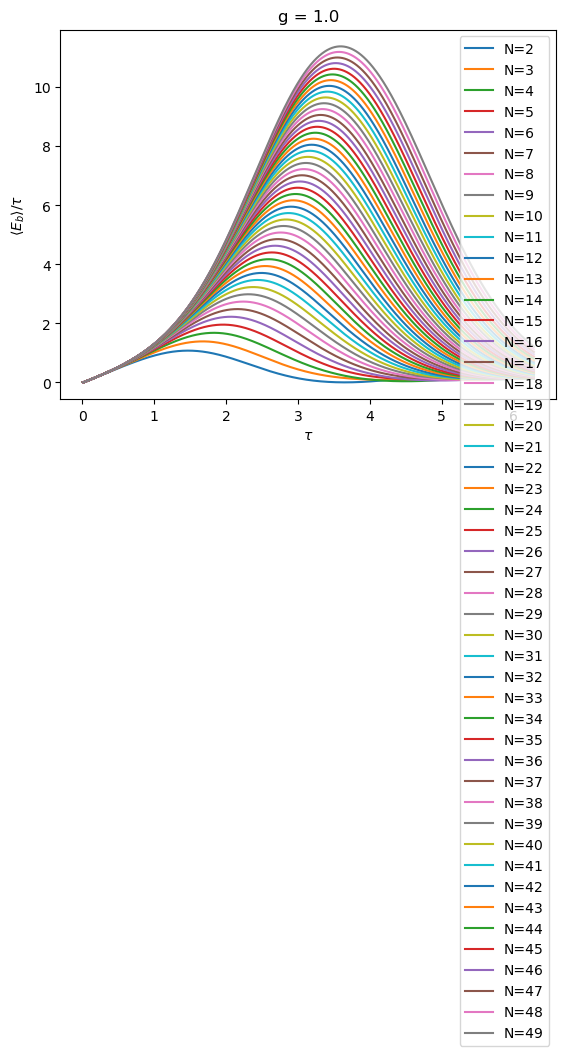

In [72]:
##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB_full, HB_red = dicke_chain(N, nc, ω, ω0, g)
    
    # Initial state
    ψ0 = initial_state_dicke(N, nc)

    opts = qt.Options(atol=1e-8, rtol=1e-6)      ## ODE solver options
    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full, options=opts)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.4f}, E_B={Eb_list[idx]:.6f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

N= 2, τ=1.4717, Eb=1.592418, Ergotropy=1.226547, erg/Eb=0.770241745117 Variance=1.7221295214e+00
N= 3, τ=1.6764, Eb=2.339649, Ergotropy=1.774401, erg/Eb=0.758404741109 Variance=3.4289786932e+00
N= 4, τ=1.8328, Eb=3.092409, Ergotropy=2.334783, erg/Eb=0.755004605990 Variance=5.7221430587e+00
N= 5, τ=1.9593, Eb=3.850213, Ergotropy=2.909109, erg/Eb=0.755570763003 Variance=8.4059900565e+00
N= 6, τ=2.0658, Eb=4.613000, Ergotropy=3.491743, erg/Eb=0.756935451612 Variance=1.1587402658e+01
N= 7, τ=2.1577, Eb=5.379980, Ergotropy=4.083281, erg/Eb=0.758977074605 Variance=1.5252725720e+01
N= 8, τ=2.2387, Eb=6.151144, Ergotropy=4.684385, erg/Eb=0.761547031448 Variance=1.8931433442e+01
N= 9, τ=2.3112, Eb=6.926478, Ergotropy=5.293313, erg/Eb=0.764214233207 Variance=2.3547626003e+01
N=10, τ=2.3769, Eb=7.705243, Ergotropy=5.905493, erg/Eb=0.766425253199 Variance=2.8342299067e+01
N=11, τ=2.4372, Eb=8.488654, Ergotropy=6.528252, erg/Eb=0.769056269101 Variance=3.3881506841e+01
N=12, τ=2.4928, Eb=9.274727, E

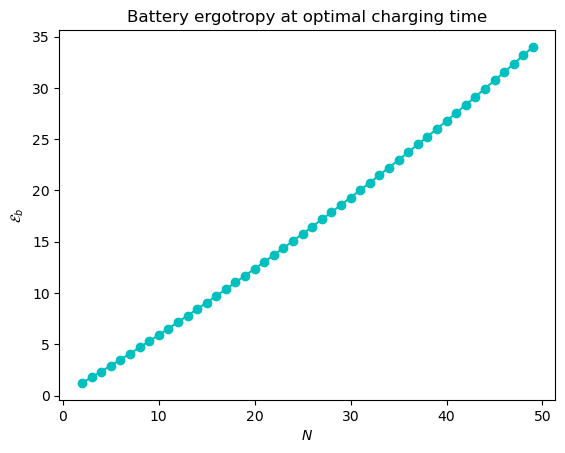

In [73]:
Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB_full, HB_red = dicke_chain(N, nc, ω, ω0, g)

    # Initial state
    ψ0 = initial_state_dicke(N, nc)

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ], options=opts)

    # Full density matrix at τ
    ρ_full = result.states[-1]

    ρb = qt.ket2dm(ρ_full)
    
    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(0)
    
    Eb = qt.expect(HB_red, ρb)
    
    pnm, r_val, e_val = pnm_matrix(ρb, HB_red)

    # Ergotropy via pnm matrix
    erg = ergotropy_pnm(pnm, r_val, e_val)

    # Variance via pnm matrix
    var = variance_pnm(pnm, r_val, e_val)

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.4f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("WS1.png")
plt.show()

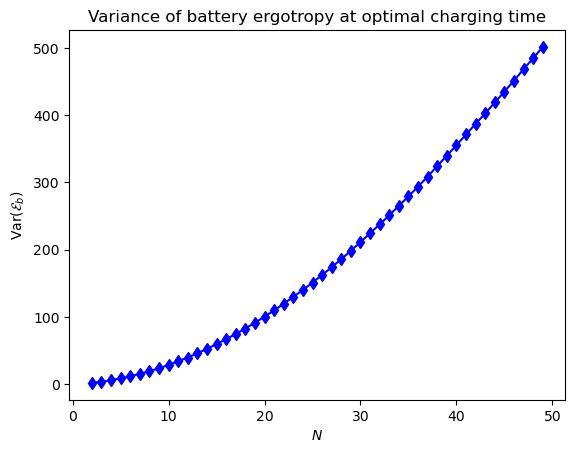

In [74]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("WS2.png")
plt.show()

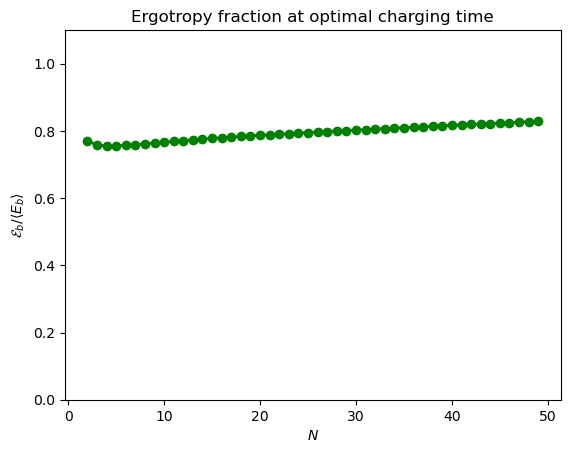

In [75]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("WS3.png")
plt.show()

N= 2, τ=1.4717, Relative Fluctuation =1.069913646805, Relative Fluctuation with Eb =0.824092154439
N= 3, τ=1.6764, Relative Fluctuation =1.043591713856, Relative Fluctuation with Eb =0.791464903570
N= 4, τ=1.8328, Relative Fluctuation =1.024549121517, Relative Fluctuation with Eb =0.773539305808
N= 5, τ=1.9593, Relative Fluctuation =0.996631280888, Relative Fluctuation with Eb =0.753025457333
N= 6, τ=2.0658, Relative Fluctuation =0.974879135892, Relative Fluctuation with Eb =0.737920578993
N= 7, τ=2.1577, Relative Fluctuation =0.956454717683, Relative Fluctuation with Eb =0.725927203619
N= 8, τ=2.2387, Relative Fluctuation =0.928836210764, Relative Fluctuation with Eb =0.707352459009
N= 9, τ=2.3112, Relative Fluctuation =0.916739519304, Relative Fluctuation with Eb =0.700585388796
N=10, τ=2.3769, Relative Fluctuation =0.901490963352, Relative Fluctuation with Eb =0.690925439843
N=11, τ=2.4372, Relative Fluctuation =0.891629483162, Relative Fluctuation with Eb =0.685713243741
N=12, τ=2.

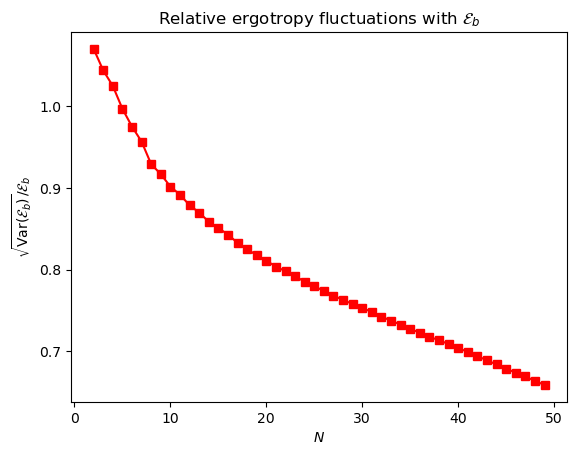

In [76]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={rel_fluct[idx]:.12f}, Relative Fluctuation with Eb ={rel_fluc[idx]:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
#plt.savefig("WS4.png")
plt.show()

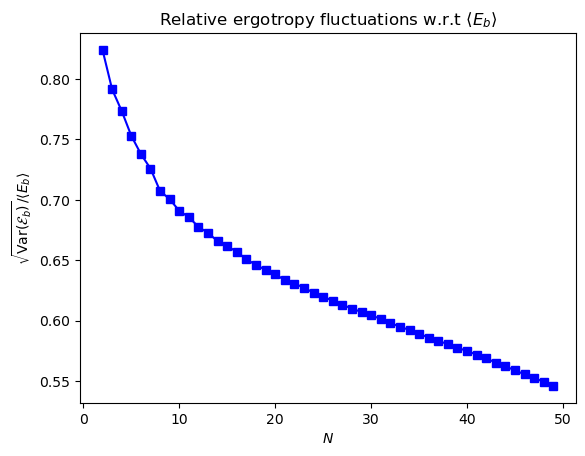

In [77]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
#plt.savefig("WS5.png")
plt.show()